In [10]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [11]:
# 1. Load dữ liệu đã tiền xử lý
df = pd.read_csv('dataset/dataset_preprocessed.csv')

# Tính toán 2 đặc trưng mới
df['failed_burden'] = np.where(df['1st_sem_enrolled'] == 0, 0, df['1st_sem_failed'] / df['1st_sem_enrolled'])
df['ghosting_rate'] = np.where(df['1st_sem_enrolled'] == 0, 0, df['1st_sem_without_evaluations'] / df['1st_sem_enrolled'])

X = df.drop(columns=['Target'])
y = df['Target']

print("Các đặc trưng đầu vào (9 features):\n", X.columns.tolist())

Các đặc trưng đầu vào (9 features):
 ['1st_sem_enrolled', '1st_sem_evaluations', '1st_sem_without_evaluations', '1st_sem_approved', '1st_sem_failed', '1st_sem_grade', '1st_sem_pass_rate', 'failed_burden', 'ghosting_rate']


In [12]:
# 2. Chia tập Train/Test (stratify để giữ tỷ lệ nhãn gốc)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)
print(f"Kích thước Train: {X_train.shape}, Test: {X_test.shape}")

Kích thước Train: (3539, 9), Test: (885, 9)


In [13]:
# BƯỚC 1: Xây dựng Mô hình 1 (Safe vs At-Risk) bằng Random Forest
y_train_stage1 = np.where(y_train == 'Safe', 'Safe', 'At-Risk')
y_test_stage1 = np.where(y_test == 'Safe', 'Safe', 'At-Risk')

rf_model1 = RandomForestClassifier(
    n_estimators=300, 
    random_state=42,
    class_weight='balanced', 
    max_depth=10
)
rf_model1.fit(X_train, y_train_stage1)
print("Đã huấn luyện xong Mô hình 1: Random Forest (Safe vs At-Risk)")

Đã huấn luyện xong Mô hình 1: Random Forest (Safe vs At-Risk)


In [14]:
# BƯỚC 2: Xây dựng Mô hình 2 (Caution vs Dropout) với SMOTE + XGBoost
# Lọc ra nhóm At-Risk từ tập Train
mask_train_at_risk = (y_train != 'Safe')
X_train_stage2 = X_train[mask_train_at_risk]
y_train_stage2 = y_train[mask_train_at_risk]

# XGBoost yêu cầu nhãn dạng số nguyên (0 và 1)
# Ánh xạ: Caution -> 0, Dropout -> 1
y_train_stage2_num = np.where(y_train_stage2 == 'Caution', 0, 1)

# --- ÁP DỤNG SMOTE ---
smote = SMOTE(random_state=42)
X_train_stage2_smote, y_train_stage2_smote = smote.fit_resample(X_train_stage2, y_train_stage2_num)

# Khởi tạo và huấn luyện XGBoost
# (Đã bỏ scale_pos_weight vì SMOTE đã cân bằng tỷ lệ Caution/Dropout về 1:1)
xgb_model2 = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model2.fit(X_train_stage2_smote, y_train_stage2_smote)
print("Đã huấn luyện xong Mô hình 2: SMOTE + XGBoost (Caution vs Dropout)")

Đã huấn luyện xong Mô hình 2: SMOTE + XGBoost (Caution vs Dropout)


In [15]:
# --- HÀM DỰ ĐOÁN 2 BƯỚC VỚI NGƯỠNG TÙY CHỈNH ---
def two_stage_predict(X_data, model1, model2, caution_threshold=0.45):
    # 1. Dự đoán bằng Mô hình 1
    stage1_preds = model1.predict(X_data)
    final_preds = np.array(stage1_preds, dtype=object)
    
    # 2. Xử lý nhóm At-Risk
    at_risk_mask = (stage1_preds == 'At-Risk')
    if np.sum(at_risk_mask) > 0:
        X_at_risk = X_data[at_risk_mask]
        
        # Lấy xác suất từ XGBoost (Cột 0 là Caution, Cột 1 là Dropout)
        stage2_probs = model2.predict_proba(X_at_risk)
        
        # Nếu xác suất của lớp 0 (Caution) >= caution_threshold -> Gán Caution, ngược lại Dropout
        stage2_preds = np.where(stage2_probs[:, 0] >= caution_threshold, 'Caution', 'Dropout')
        
        # Cập nhật kết quả
        final_preds[at_risk_mask] = stage2_preds
        
    return final_preds

=== BÁO CÁO PHÂN LOẠI (RF + SMOTE + XGBoost) ===
              precision    recall  f1-score   support

     Caution       0.34      0.42      0.38       159
     Dropout       0.72      0.57      0.63       284
        Safe       0.77      0.80      0.79       442

    accuracy                           0.66       885
   macro avg       0.61      0.60      0.60       885
weighted avg       0.67      0.66      0.66       885



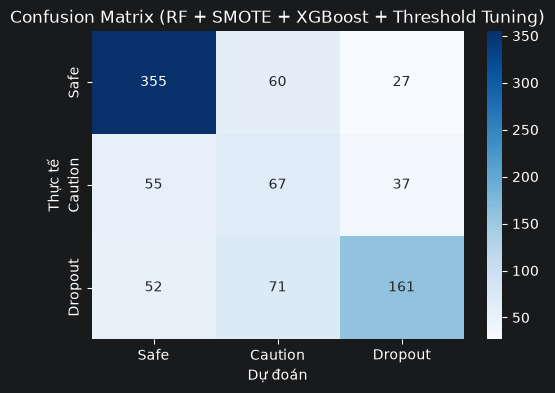

In [16]:
# ĐÁNH GIÁ MÔ HÌNH
# Tinh chỉnh ngưỡng Caution (ví dụ: 0.45 do SMOTE đã đẩy tỷ lệ 2 lớp về cân bằng)
y_pred = two_stage_predict(X_test, rf_model1, xgb_model2, caution_threshold=0.45)

print("=== BÁO CÁO PHÂN LOẠI (RF + SMOTE + XGBoost) ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['Safe', 'Caution', 'Dropout'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Safe', 'Caution', 'Dropout'], 
            yticklabels=['Safe', 'Caution', 'Dropout'])
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.title('Confusion Matrix (RF + SMOTE + XGBoost + Threshold Tuning)')
plt.show()

In [17]:
# Khởi tạo Semantic Features cho CBF (Hệ thống Khuyến nghị) - Bản cập nhật 6 chiều
def create_raw_semantic_features(df_features):
    semantic_df = pd.DataFrame()
    max_grade = df_features['1st_sem_grade'].max() if df_features['1st_sem_grade'].max() > 0 else 20

    semantic_df['low_grade'] = max_grade - df_features['1st_sem_grade']
    semantic_df['low_pass_rate'] = 1 - df_features['1st_sem_pass_rate']
    semantic_df['failed_burden'] = df_features['failed_burden']
    semantic_df['evaluation_issue'] = df_features['ghosting_rate']

    # CHIỀU DỮ LIỆU MỚI: workload_gap (chênh lệch giữa số môn đăng ký và số môn đạt)
    semantic_df['workload_gap'] = np.where(df_features['1st_sem_enrolled'] == 0, 0, (df_features['1st_sem_enrolled'] - df_features['1st_sem_approved']) / df_features['1st_sem_enrolled'])

    semantic_df['high_performance'] = df_features['1st_sem_grade'] * df_features['1st_sem_pass_rate']
    return semantic_df

raw_semantic_train = create_raw_semantic_features(X_train)
scaler = MinMaxScaler()
scaler.fit(raw_semantic_train)

print("Fit Scaler thành công với 6 chiều dữ liệu!")
print("Các chiều:", raw_semantic_train.columns.tolist())

Fit Scaler thành công với 6 chiều dữ liệu!
Các chiều: ['low_grade', 'low_pass_rate', 'failed_burden', 'evaluation_issue', 'workload_gap', 'high_performance']


In [18]:
# Lưu tất cả file Models
os.makedirs('models', exist_ok=True)

joblib.dump(rf_model1, 'models/rf_model1.pkl')
joblib.dump(xgb_model2, 'models/xgb_model2.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(list(X.columns), 'models/feature_columns.pkl')

print("Đã lưu các file model vào thư mục 'models/':")
print("- rf_model1.pkl (Random Forest)")
print("- xgb_model2.pkl (XGBoost)")
print("- feature_columns.pkl")
print("- scaler.pkl")

Đã lưu các file model vào thư mục 'models/':
- rf_model1.pkl (Random Forest)
- xgb_model2.pkl (XGBoost)
- feature_columns.pkl
- scaler.pkl
